### For each cell type shared, perform the comparison between our DEG list (using pseudobulked analysis) and Read DEG list

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_significant(df, direction, logFC_threshold = 0.5, p_val_threshold = 0.05):
    '''Get either the significant up or down DEGs from a pydeseq2 directory''' 
    if direction == "up":
        sig_df = df[(df['log2FoldChange'] > logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    elif direction == "down":
        sig_df = df[(df['log2FoldChange'] < -logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    else: 
        raise ValueError("direction must be 'up' or 'down'!")
    return sig_df

In [3]:
def compare_DEGs(our_df, read_df, our_gene_col="gene_id", read_gene_col="gene", 
                 our_direction_col="direction", read_direction_col = "Effect_Direction"):
    '''Compare DEGs between our dataset and Read et al.'''
    
    # generate sets
    our_up   = set(our_df.loc[our_df[our_direction_col]=="up",   our_gene_col])
    our_down = set(our_df.loc[our_df[our_direction_col]=="down", our_gene_col])
    
    read_up   = set(read_df.loc[read_df[read_direction_col]=="Positive",   read_gene_col])
    read_down = set(read_df.loc[read_df[read_direction_col]=="Negative", read_gene_col])
    
    results = {
        "shared_up":   len(our_up & read_up),
        "shared_down": len(our_down & read_down),
        "up_only_ours": len(our_up - read_up),
        "down_only_ours": len(our_down - read_down),
        "up_only_Read": len(read_up - our_up),
        "down_only_Read": len(read_down - our_down),
    }
    
    return results

### Test for one cell type

In [4]:
Read_DEG_df = pd.read_csv("Read_sex_DEG_df/Adipocyte_DEG.csv", index_col = 0)
Read_DEG_df

,gene,coefficientValue,q_val,pval,cellType,Effect_Magnitude,Effect_Direction,consistent_cell_type
67492,UTY,4.923853,7.730000e-154,1.100000e-157,Adipocytes,4.923853,Positive,Adipocyte
67493,TBL1Y,4.880089,8.750000e-58,4.960000e-61,Adipocytes,4.880089,Positive,Adipocyte
67494,RPS4Y1,4.783918,1.240000e-63,5.280000e-67,Adipocytes,4.783918,Positive,Adipocyte
67495,ZFY,4.378611,2.580000e-51,1.830000e-54,Adipocytes,4.378611,Positive,Adipocyte
67496,USP9Y,4.186548,1.690000e-99,4.790000e-103,Adipocytes,4.186548,Positive,Adipocyte
67497,CEACAM8,-1.109745,1.088344e-03,1.540000e-06,Adipocytes,1.109745,Negative,Adipocyte
67523,GYG2,-0.584796,7.683724e-03,1.310000e-05,Adipocytes,0.584796,Negative,Adipocyte
67543,CD99,0.527128,3.410000e-05,3.870000e-08,Adipocytes,0.527128,Positive,Adipocyte
67565,FLACC1,-0.472103,1.365868e-02,2.710000e-05,Adipocytes,0.472103,Negative,Adipocyte
67576,THAP4,0.453838,1.395822e-02,2.970000e-05,Adipocytes,0.453838,Positive,Adipocyte


In [5]:
our_DEG_df = pd.read_csv("../pydeseq2_results/Adipocyte_sex_male_vs_female_results.csv", index_col = 0)
our_DEG_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant
XIST,111.902012,-8.064242,0.312281,-25.823633,4.813452e-147,7.743882e-143,XIST,142.111041,True
LINC00278,88.059980,7.206059,0.365174,19.733198,1.118641e-86,8.998349e-83,LINC00278,82.045837,True
USP9Y,30.684964,5.845443,0.300495,19.452742,2.762541e-84,1.481459e-80,USP9Y,79.829310,True
UTY,33.476176,5.971134,0.313907,19.022009,1.121040e-80,4.508821e-77,UTY,76.345937,True
TTTY14,46.494880,6.141131,0.332165,18.488221,2.568899e-76,8.265691e-73,TTTY14,72.082721,True
...,...,...,...,...,...,...,...,...,...
DYNLT1,10.834281,0.000094,0.194468,0.000482,9.996151e-01,9.998394e-01,DYNLT1,0.000070,False
IRAK2,13.428607,-0.000183,0.263961,-0.000692,9.994481e-01,9.998394e-01,IRAK2,0.000070,False
THEG,1.250281,-0.000141,0.450419,-0.000313,9.997503e-01,9.998746e-01,THEG,0.000054,False
KBTBD7,2.426030,-0.000052,0.281628,-0.000184,9.998535e-01,9.999157e-01,KBTBD7,0.000037,False


In [6]:
sig_df = extract_significant(our_DEG_df, direction="up")
sig_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant,direction
LINC00278,88.059980,7.206059,0.365174,19.733198,1.118641e-86,8.998349e-83,LINC00278,82.045837,True,up
USP9Y,30.684964,5.845443,0.300495,19.452742,2.762541e-84,1.481459e-80,USP9Y,79.829310,True,up
UTY,33.476176,5.971134,0.313907,19.022009,1.121040e-80,4.508821e-77,UTY,76.345937,True,up
TTTY14,46.494880,6.141131,0.332165,18.488221,2.568899e-76,8.265691e-73,TTTY14,72.082721,True,up
RPS4Y1,13.528661,5.126730,0.330403,15.516615,2.678108e-54,7.180899e-51,RPS4Y1,50.143821,True,up
TTTY10,13.257172,4.959465,0.345727,14.345028,1.144541e-46,2.630481e-43,TTTY10,42.579965,True,up
ZFY,10.115795,4.123785,0.311268,13.248353,4.612120e-40,8.244421e-37,ZFY,36.083840,True,up
TBL1Y,12.816059,4.478992,0.355151,12.611529,1.824181e-36,2.934742e-33,TBL1Y,32.532430,True,up
KDM5D,7.913343,4.450623,0.355224,12.529054,5.177682e-36,7.572596e-33,KDM5D,32.120755,True,up
DDX3Y,5.627502,4.092241,0.360474,11.352381,7.216984e-30,9.675570e-27,DDX3Y,26.014323,True,up


### Iterate through all cell types

In [7]:
shared_cell_types = ['Adipocyte', 'Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Lymphoid', 'Neuronal', 'Pericyte']

In [8]:
results_list = list()

for cell_type in shared_cell_types:

    # load in the Read df (NEBULA) and our DEG df (pseudobulked method)
    Read_DEG_df = pd.read_csv("Read_sex_DEG_df/" + cell_type + "_DEG.csv", index_col = 0)
    our_DEG_df = pd.read_csv("../pydeseq2_results/" + cell_type + "_sex_male_vs_female_results.csv", index_col = 0)

    # extract significant up DEGs
    sig_up_df = extract_significant(our_DEG_df, direction="up")
    sig_down_df = extract_significant(our_DEG_df, direction="down")
    concat_sig_df = pd.concat([sig_up_df, sig_down_df])
    
    # compare up DEGs
    results = compare_DEGs(our_df=concat_sig_df, read_df=Read_DEG_df)
    results['cell_type'] = cell_type

    # append both
    results_list.append(results)

results_df = pd.DataFrame(results_list)

In [9]:
results_df

,shared_up,shared_down,up_only_ours,down_only_ours,up_only_Read,down_only_Read,cell_type
0,5,2,8,3,11,7,Adipocyte
1,40,11,57,23,62,26,Cardiomyocyte
2,9,5,8,6,4,11,Endothelial
3,11,8,14,12,5,13,Fibroblast
4,7,8,7,8,2,8,Lymphoid
5,2,7,9,11,1,2,Neuronal
6,8,3,6,7,4,7,Pericyte


/mnt/data1/william/tmp/ipykernel_298196/1662348943.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))


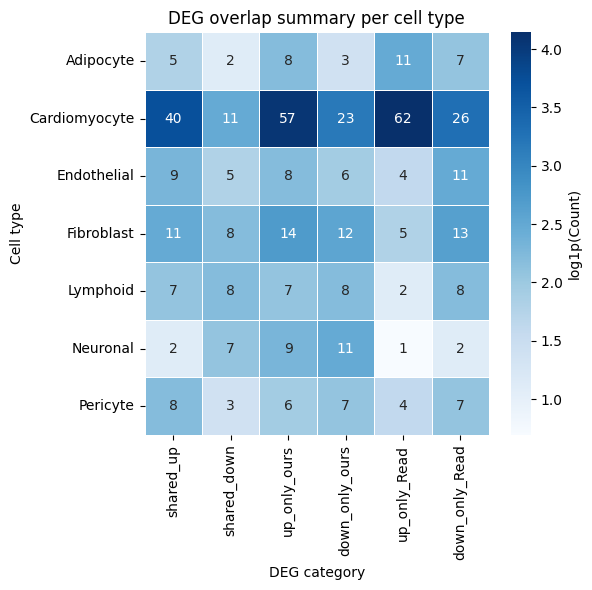

<Figure size 640x480 with 0 Axes>

In [10]:
# Select metrics
heatmap_df = results_df.set_index("cell_type")[
    ["shared_up", "shared_down", "up_only_ours", "down_only_ours", "up_only_Read", "down_only_Read"]
]

custom_order = shared_cell_types

heatmap_df = heatmap_df.reindex(custom_order)

# colors on log scale
heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))

plt.figure(figsize=(6,6))
sns.heatmap(
    heatmap_colors,
    cmap="Blues",           
    annot=heatmap_df,      
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "log1p(Count)"}
)
plt.title("DEG overlap summary per cell type")
plt.ylabel("Cell type")
plt.xlabel("DEG category")
plt.tight_layout()
plt.show()

plt.savefig("Read_vs_our_study_sex_DEGs.pdf")